First, liftover hg19 variants to hg38 (or as appropriate for your data)

In [1]:
#BiocManager::install("biomaRt")

In [2]:
#BiocManager::install("rtracklayer")

# Run SCAVENGE

## Create Summarized Experiment from single-cell dataset

In [5]:
#remotes::install_github("https://github.com/sankaranlab/SCAVENGE")

In [6]:
#devtools::install_github("caleblareau/BuenColors")
#BiocManager::install("BSgenome.Hsapiens.UCSC.hg38")

In [1]:
library(tidyr)
library(biomaRt)
library(rtracklayer)
library(Seurat)
library(SCAVENGE)
library(chromVAR)
library(SummarizedExperiment)
library(data.table)
library(dplyr)
library(BiocParallel)
library(igraph)
library(gchromVAR)
library(BuenColors)
library(BSgenome.Hsapiens.UCSC.hg38)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect




Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowL

In [2]:
hg38_filtered_wnn <- readRDS("~/JAN_028/JAN_028_wnn_object.rds")
DefaultAssay(hg38_filtered_wnn) <- 'ATAC'

In [3]:
colData<-hg38_filtered_wnn@meta.data[c("orig.ident","gene","seurat_clusters","john_dick_annotation_simplified")]
umap_data <- as.data.frame(Embeddings(hg38_filtered_wnn, "wnn.umap"))
colDATA <- merge(colData, umap_data, by = "row.names")

In [4]:
peaks_list <- rownames(hg38_filtered_wnn)

parse_peak <- function(peak_str) {
  parts <- strsplit(peak_str, "-")[[1]]
  seqname <- parts[1]
  start <- as.integer(parts[2])
  end <- as.integer(parts[3])
  gr <- GRanges(seqnames = seqname, ranges = IRanges(start = start, end = end))
  return(gr)
}

gr_list <- lapply(peaks_list, parse_peak)

rowRanges <- do.call(c, gr_list)

# Keep only standard chromosomes
all_seqlevels = seqlevels(rowRanges) 
desired_seqlevels <- c(paste0("chr", 1:22), "chrX", "chrY")
filtered_seqlevels <- all_seqlevels[all_seqlevels %in% desired_seqlevels]

filtered_grange_obj <- rowRanges[seqnames(rowRanges) %in% filtered_seqlevels]

Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warn

In [5]:
rows_to_keep <- grep(paste(filtered_seqlevels, collapse = "|"), rownames(hg38_filtered_wnn))
peak_matrix <- hg38_filtered_wnn@assays$ATAC@counts[rows_to_keep, ]


In [6]:
SE_hg38 <- SummarizedExperiment(assays=list(counts=peak_matrix), rowRanges=filtered_grange_obj, colData=colDATA)
#saveRDS(SE_hg38, file = "~/JAN_037_SCAVENGE/hg38_coord/SEhg38.RDS")

## For credible sets of variants

### Extract TF-sensitive credible sets

In [7]:
trait_names <- c("HCT","RBC", "RDW", "MCV", "MCHC", "MCH", "HGB", "BAS", "EOS", "WBC", "MON", "NEU", "PLT", "LYM")
base_path <- "~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/"

for (trait_name in trait_names) {
  file_path <- paste0(base_path,"/hg38_liftover/", trait_name, "_hg38_credible_sets.csv")
  trait <- read.csv(file_path)
  trait_TF_sens <- trait[trait$credible_set_class == "credible_sets_tf_sensitive", ]
  #write.csv(trait_TF_sens, paste0(base_path, "TF_sensitive/", trait_name, "_TF_sensitive_credible_sets.csv"), row.names = FALSE)
}


In [8]:
trait_names <- c("HCT","RBC", "RDW", "MCV", "MCHC", "MCH", "HGB", "BAS", "EOS", "WBC", "MON", "NEU", "PLT", "LYM")

for (trait_name in trait_names) {
trait <- read.csv(paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/TF_sensitive/",trait_name,"_TF_sensitive_credible_sets.csv"))
trait_TF_sens <- trait[,c(1:3,6,16,20)]  
#write.table(trait_TF_sens, paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/TF_sensitive/",trait_name,"_TF_sensitive.bed"), sep = "\t")
}



### Run Scavenge for TF-sensitive credible sets

In [9]:
hg38_filtered_wnn <- readRDS("~/JAN_028/JAN_028_wnn_object.rds")
DefaultAssay(hg38_filtered_wnn) <- 'ATAC'

SE_hg38 <- readRDS("~/JAN_037_SCAVENGE/hg38_coord/SEhg38.RDS")

gc_SE_hg38 <- addGCBias(object = SE_hg38, 
                       genome = BSgenome.Hsapiens.UCSC.hg38::BSgenome.Hsapiens.UCSC.hg38)

SE_hg38_bp <- getBackgroundPeaks(object = gc_SE_hg38, 
                                   niterations = 200)

peak_by_cell_mat <- SummarizedExperiment::assay(SE_hg38)
tfidf_mat <- tfidf(bmat=peak_by_cell_mat, 
                   mat_binary=TRUE, 
                   TF=TRUE, 
                   log_TF=TRUE)

lsi_mat <- do_lsi(mat = tfidf_mat, 
                  dims = 30)

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270934v1_alt, chr3_KI270935v1_alt

[info] binarize matrix

[info] calculate tf

[info] calculate idf

[info] fast log tf-idf

SVD analysis of TF-IDF matrix



In [10]:
Trait_list = c("EOS","BAS","HCT","HGB","LYM","MCHC","MCH","MCV","MON","NEU","PLT","RBC","RDW","WBC")

for (Trait_name in Trait_list) {
Trait_filt <- importBedScore(rowRanges(SE_hg38), paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/TF_sensitive/",Trait_name,"_TF_sensitive.bed"), colidx=5)
SE_hg38_DEV <- computeWeightedDeviations(object = gc_SE_hg38, 
                                           weights = Trait_filt, 
                                           background_peaks = SE_hg38_bp)

z_score_mat <- data.frame(SummarizedExperiment::colData(SE_hg38), 
                          z_score=t(SummarizedExperiment::assays(SE_hg38_DEV)[["z"]]) |> c())

seed_idx <- seedindex(z_score = z_score_mat$z_score,
                      percent_cut = 0.05)

scale_factor <- cal_scalefactor(z_score = z_score_mat$z_score, 
                                percent_cut = 0.01)

mutualknn30 <- getmutualknn(lsimat = lsi_mat, 
                            num_k = 30)

np_score <- randomWalk_sparse(intM = mutualknn30, 
                              queryCells = rownames(mutualknn30)[seed_idx], 
                              gamma = 0.05)

omit_idx <- np_score==0
sum(omit_idx)


mutualknn30 <- mutualknn30[!omit_idx, !omit_idx]
np_score <- np_score[!omit_idx]
TRS <- capOutlierQuantile(x = np_score, 
                          q_ceiling = 0.95) |> max_min_scale()
TRS <- TRS * scale_factor
sample <- data.frame(z_score_mat[!omit_idx, ], 
                       seed_idx[!omit_idx], 
                       np_score, 
                       TRS)

matching_rows <- match(rownames(sample), rownames(hg38_filtered_wnn@meta.data))
sample$john_dick_annotation_simplified <- hg38_filtered_wnn@meta.data$john_dick_annotation_simplified[matching_rows]    

#write.table(sample, paste0("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NewAnnotations/TF_sensitive/", Trait_name, "_TF_sensitive_credible_set_matrix_NewAnnotations.txt"), sep = "\t")

   }

Cells with enriched P < 0.05: 13235

Percent: 9.62%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 101

Stationary Delta: 9.90171021885436e-06

Cells with enriched P < 0.05: 10263

Percent: 7.46%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 102

Stationary Delta: 9.87197860256893e-06

Cells with enriched P < 0.05: 9190

Percent: 6.68%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 106

Stationary Delta: 9.73614567409089e-06

Cells with enriched P < 0.05: 9504

Percent: 6.91%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 114

Stationary Delta: 9.52072995310828e-06

### Extract non-TF-sensitive credible sets

In [11]:
trait_names <- c("HCT","RBC", "RDW", "MCV", "MCHC", "MCH", "HGB", "BAS", "EOS", "WBC", "MON", "NEU", "PLT", "LYM")
base_path <- "~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/"

for (trait_name in trait_names) {
  file_path <- paste0(base_path,"/hg38_liftover/", trait_name, "_hg38_credible_sets.csv")
  trait <- read.csv(file_path)
  trait_TF_sens <- trait[trait$credible_set_class == "credible_sets_NOT_tf_sensitive", ]
  #write.csv(trait_TF_sens, paste0(base_path, "NOT_TF_sensitive/", trait_name, "_NOT_TF_sensitive_credible_sets.csv"), row.names = FALSE)
}


In [12]:
trait_names <- c("HCT","RBC", "RDW", "MCV", "MCHC", "MCH", "HGB", "BAS", "EOS", "WBC", "MON", "NEU", "PLT", "LYM")

for (trait_name in trait_names) {
trait <- read.csv(paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/",trait_name,"_NOT_TF_sensitive_credible_sets.csv"))
trait_TF_sens <- trait[,c(1:3,6,16,20)]  
#write.table(trait_TF_sens, paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/",trait_name,"_NOT_TF_sensitive.bed"), sep = "\t")
}


### Run Scavenge for non-TF-sensitive credible sets

In [13]:
Trait_list = c("EOS","HCT","HGB","LYM","MCHC","MCH","MCV","MON","NEU","PLT","RBC","RDW","WBC") #Remove BAS as no enrichment is found

for (Trait_name in Trait_list) {
Trait_filt <- importBedScore(rowRanges(SE_hg38), paste0("~/JAN_037_SCAVENGE/hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/",Trait_name,"_NOT_TF_sensitive.bed"), colidx=5)

SE_hg38_DEV <- computeWeightedDeviations(object = gc_SE_hg38, 
                                           weights = Trait_filt, 
                                           background_peaks = SE_hg38_bp)

z_score_mat <- data.frame(SummarizedExperiment::colData(SE_hg38), 
                          z_score=t(SummarizedExperiment::assays(SE_hg38_DEV)[["z"]]) |> c())

seed_idx <- seedindex(z_score = z_score_mat$z_score,
                      percent_cut = 0.05)

scale_factor <- cal_scalefactor(z_score = z_score_mat$z_score, 
                                percent_cut = 0.01)

mutualknn30 <- getmutualknn(lsimat = lsi_mat, 
                            num_k = 30)

np_score <- randomWalk_sparse(intM = mutualknn30, 
                              queryCells = rownames(mutualknn30)[seed_idx], 
                              gamma = 0.05)

omit_idx <- np_score==0
sum(omit_idx)

mutualknn30 <- mutualknn30[!omit_idx, !omit_idx]
np_score <- np_score[!omit_idx]
TRS <- capOutlierQuantile(x = np_score, 
                          q_ceiling = 0.95) |> max_min_scale()
TRS <- TRS * scale_factor
sample <- data.frame(z_score_mat[!omit_idx, ], 
                       seed_idx[!omit_idx], 
                       np_score, 
                       TRS)

matching_rows <- match(rownames(sample), rownames(hg38_filtered_wnn@meta.data))
sample$john_dick_annotation_simplified <- hg38_filtered_wnn@meta.data$john_dick_annotation_simplified[matching_rows]    

    
#write.table(Trait_filt, paste0("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NewAnnotations/TF_NON_sensitive/", Trait_name, "_NOT_TF_sensitive_credible_set_matrix.txt"), sep = "\t")

   }

Cells with enriched P < 0.05: 10721

Percent: 7.79%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 112

Stationary Delta: 9.62206883977821e-06

Cells with enriched P < 0.05: 8986

Percent: 6.53%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 108

Stationary Delta: 9.90490335587802e-06

Cells with enriched P < 0.05: 9145

Percent: 6.65%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

Stationary step: 103

Stationary Delta: 9.93746881115232e-06

Stationary step: 103

Stationary Delta: 9.68480571246275e-06

Cells with enriched P < 0.05: 10336

Percent: 7.51%

The top 5% of cells (N=6880) were selected as seed cells

Scale factor is calculating from most enriched 1% of cells.

[info] fast knn

### Heatmaps - All traits

#### TF-sensitive credible sets

In [14]:
library(ComplexHeatmap)
library("RColorBrewer")
library(circlize)
library(psych)
library(broom)
library(tidyr)

Loading required package: grid


Attaching package: ‘grid’


The following object is masked from ‘package:Biostrings’:

    pattern


ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.

In [15]:
RBC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/RBC_TF_sensitive_credible_set_matrix.txt",header = TRUE, sep = "\t", row.names = 1)
RDW <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/RDW_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCV <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCV_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCH <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCH_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCHC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCHC_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
HCT <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/HCT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
HGB <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/HGB_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Eo <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/EOS_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Baso <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/BAS_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
WBC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/WBC_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Neutro <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NEU_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Mono <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MON_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Lympho <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/LYM_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
PLT <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/PLT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)

data_frame_names <- c('RBC', 'RDW', 'MCH','MCV', 'MCHC', 'HCT', 'HGB', 'EOS', 'BAS', 'WBC', 'NEU', 'MON', 'LYM', 'PLT')

summary_stats_list <- list()

for (df_name in data_frame_names) {
  df <- read.table(paste0("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NewAnnotations/TF_sensitive/", df_name, "_TF_sensitive_credible_set_matrix_NewAnnotations.txt"), header = TRUE, sep = "\t", row.names = 1)
  mean_df <- df %>%
    group_by(john_dick_annotation_simplified) %>%
    summarise(mean_TRS = mean(TRS))
  summary_stats_list[[df_name]] <- mean_df
}

combined_stats <- bind_rows(summary_stats_list, .id = "Trait")
combined_stats_wide <- pivot_wider(combined_stats, names_from = Trait, values_from = mean_TRS)
combined_stats_wide <- as.data.frame(combined_stats_wide)
rownames(combined_stats_wide) <- combined_stats_wide$john_dick_annotation_simplified
combined_stats_wide <- combined_stats_wide [,-1]

#write.csv(combined_stats_wide, "~/JAN_037_SCAVENGE//hg38_coord//Scavenge_matrix/NewAnnotations/TF_sensitive/Mean_TRS_TF_sensitive_credible_sets.csv")


In [16]:
cell_number <- as.data.frame(table(hg38_filtered_wnn$john_dick_annotation_simplified))
rownames(cell_number) <- cell_number[,1]
cell_number[1] <- NULL 
colnames(cell_number)[1] <- "n_cells"
cell_number <- arrange(cell_number, rownames(cell_number))

#write.csv(cell_number,"~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/hg38_wnn_cell_number.csv")

In [17]:
trait_objects <- list(
  RBC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/RBC_TF_sensitive.bed",  sep = "\t"),
  RDW_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/RDW_TF_sensitive.bed",  sep = "\t"),
  MCV_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/MCV_TF_sensitive.bed",  sep = "\t"),
  MCH_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/MCH_TF_sensitive.bed",  sep = "\t"),
  MCHC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/MCHC_TF_sensitive.bed",  sep = "\t"),
  HCT_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/HCT_TF_sensitive.bed",  sep = "\t"),
  HGB_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/HGB_TF_sensitive.bed",  sep = "\t"),
  EOS_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/EOS_TF_sensitive.bed", sep = "\t"),
  BAS_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/BAS_TF_sensitive.bed", sep = "\t"),
  WBC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/WBC_TF_sensitive.bed", sep = "\t"),
  NEU_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/NEU_TF_sensitive.bed", sep = "\t"),
  MON_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/MON_TF_sensitive.bed", sep = "\t"),
  LYM_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/LYM_TF_sensitive.bed", sep = "\t"),
  PLT_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/PLT_TF_sensitive.bed", sep = "\t")
)

trait_rows_df <- data.frame(Trait = character(), Rows = integer(), stringsAsFactors = FALSE)

for (trait_name in names(trait_objects)) {
  trait_object <- trait_objects[[trait_name]]
  rows_count <- nrow(trait_object)
  trait_rows_df <- bind_rows(trait_rows_df, data.frame(Trait = trait_name, Rows = rows_count))
}

rownames(trait_rows_df) <- trait_rows_df$Trait
trait_rows_df$Trait <- NULL  
rownames(trait_rows_df) <- gsub("_trait", "", rownames(trait_rows_df))
colnames(trait_rows_df)[1] <- "n_Variants"

#write.csv(trait_rows_df, "~/JAN_037_SCAVENGE//hg38_coord//BCX2_variants/credible_sets/TF_sensitive/TF_sensitive_credible_sets_number.csv")


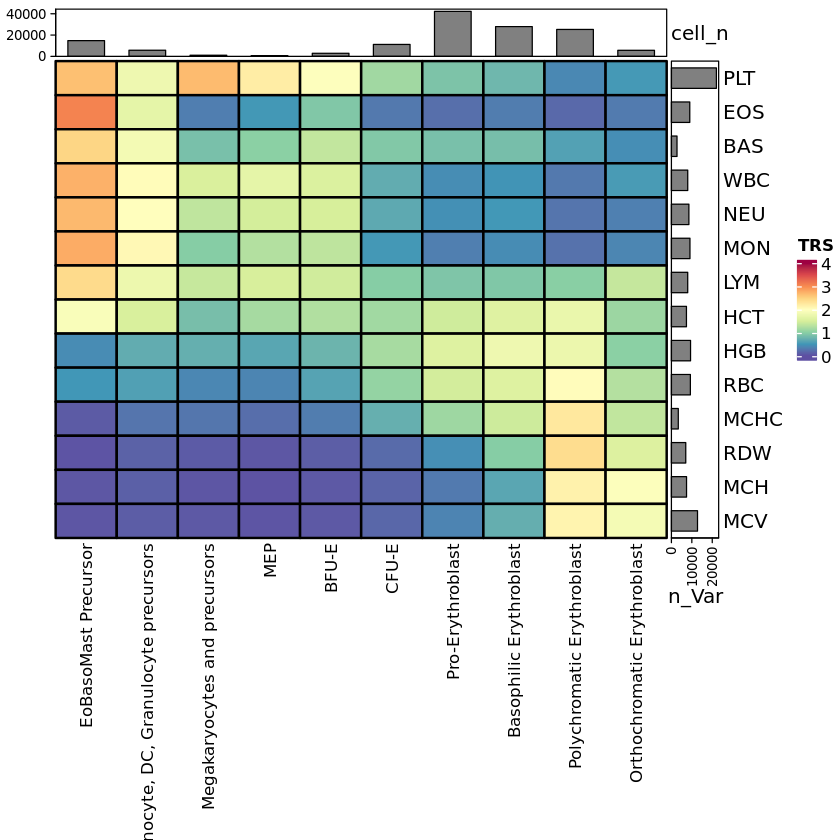

In [18]:
TF_sens_mean_traits <- read.csv("~/JAN_037_SCAVENGE//hg38_coord//Scavenge_matrix/NewAnnotations/TF_sensitive/Mean_TRS_TF_sensitive_credible_sets.csv", row.names = 1)
data <- as.matrix(t(TF_sens_mean_traits))

cell_number <- read.csv("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/hg38_wnn_cell_number.csv")
colnames(cell_number)[1] <- 'pop'

variant_num <- read.csv("~/JAN_037_SCAVENGE//hg38_coord//BCX2_variants/credible_sets/TF_sensitive/TF_sensitive_credible_sets_number.csv", row.names = 1)
desired_order <- c('RBC', 'RDW', 'MCH', 'MCV', 'MCHC', 'HCT', 'HGB', 'EOS', 'BAS', 'WBC', 'NEU', 'MON', 'LYM', 'PLT')
variant_num <- variant_num[match(desired_order, rownames(variant_num)), , drop = FALSE]

row_order <- c("PLT","EOS", "BAS", "WBC", "NEU", "MON","LYM","HCT", "HGB", "RBC", "MCHC", "RDW","MCH","MCV")
column_order <- c("EoBasoMast Precursor", "Monocyte, DC, Granulocyte precursors", "Megakaryocytes and precursors", "MEP", "BFU-E",
                        "CFU-E", "Pro-Erythroblast", "Basophilic Erythroblast", "Polychromatic Erythroblast", "Orthochromatic Erythroblast")

col1 = colorRamp2(seq(0, 4, length = 9), c('#5E4FA2', '#3F96B7', '#88CFA4', '#D7EF9B', '#FFFFBF', '#FDD380', '#F88D51', '#DC494C', '#9E0142'))
row_ha = rowAnnotation(n_Var = anno_barplot(variant_num))
column_ha = HeatmapAnnotation(cell_n = anno_barplot(cell_number$n_cells)
                        )
Heatmap(data, col = col1, column_order = column_order,name = "TRS", cluster_columns = FALSE,
        cluster_rows = FALSE, row_order = row_order,
       right_annotation = row_ha, top_annotation = column_ha, column_names_gp = gpar(fontsize = 10),
       rect_gp = gpar(col = "black", lwd = 2),
       heatmap_legend_param = list(at = seq(0, 4)))

#### Non-TF-sensitive credible sets

In [19]:
RBC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/RBC_NOT_TF_sensitive_credible_set_matrix.txt",header = TRUE, sep = "\t", row.names = 1)
RDW <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/RDW_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCV <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCV_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCH <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCH_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
MCHC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MCHC_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
HCT <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/HCT_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
HGB <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/HGB_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Eo <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/EOS_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
# the low number of non-TF-sensitive variants didn't allow the calculation of TRS score for BAS non-TF-sensitive
#Baso <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/BAS_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
WBC <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/WBC_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Neutro <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NEU_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Mono <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/MON_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
Lympho <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/LYM_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)
PLT <- read.table("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/PLT_NOT_TF_sensitive_credible_set_matrix.txt", header = TRUE, sep = "\t", row.names = 1)



In [20]:
data_frame_names <- c('RBC', 'RDW', 'MCH','MCV', 'MCHC', 'HCT', 'HGB', 'EOS', 'WBC', 'NEU', 'MON', 'LYM', 'PLT')# REMOVE BAS trait As TRS couldn't be computed

summary_stats_list <- list()

for (df_name in data_frame_names) {
  df <- read.table(paste0("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/NewAnnotations/TF_NON_sensitive/", df_name, "_NOT_TF_sensitive_credible_set_matrix.txt"), header = TRUE, sep = "\t", row.names = 1)
  mean_df <- df %>%
    group_by(john_dick_annotation_simplified) %>%
    summarise(mean_TRS = mean(TRS))
  summary_stats_list[[df_name]] <- mean_df
}

combined_stats <- bind_rows(summary_stats_list, .id = "Trait")
combined_stats_wide <- combined_stats %>%
  pivot_wider(names_from = Trait, values_from = mean_TRS)
combined_stats_wide <- pivot_wider(combined_stats, names_from = Trait, values_from = mean_TRS)
combined_stats_wide <- as.data.frame(combined_stats_wide)
rownames(combined_stats_wide) <- combined_stats_wide$john_dick_annotation_simplified
combined_stats_wide <- combined_stats_wide [,-1]

#write.csv(combined_stats_wide, "~/JAN_037_SCAVENGE//hg38_coord//Scavenge_matrix/NewAnnotations/TF_NON_sensitive/Mean_TRS_NOT_TF_sensitive_credible_sets.csv")


In [21]:
trait_objects <- list(
  RBC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/RBC_NOT_TF_sensitive.bed",  sep = "\t"),
  RDW_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/RDW_NOT_TF_sensitive.bed",  sep = "\t"),
  MCV_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/MCV_NOT_TF_sensitive.bed",  sep = "\t"),
  MCH_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/MCH_NOT_TF_sensitive.bed",  sep = "\t"),
  MCHC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/MCHC_NOT_TF_sensitive.bed",  sep = "\t"),
  HCT_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/HCT_NOT_TF_sensitive.bed",  sep = "\t"),
  HGB_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/HGB_NOT_TF_sensitive.bed",  sep = "\t"),
  EOS_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/EOS_NOT_TF_sensitive.bed", sep = "\t"),
  # the low number of non-TF-sensitive variants didn't allow the calculation of TRS score for BAS non-TF-sensitive
  #BAS_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/TF_sensitive/BAS_NOT_TF_sensitive.bed", sep = "\t"),
  WBC_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/WBC_NOT_TF_sensitive.bed", sep = "\t"),
  NEU_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/NEU_NOT_TF_sensitive.bed", sep = "\t"),
  MON_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/MON_NOT_TF_sensitive.bed", sep = "\t"),
  LYM_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/LYM_NOT_TF_sensitive.bed", sep = "\t"),
  PLT_trait = read.table("~/JAN_037_SCAVENGE//hg38_coord/BCX2_variants/credible_sets/NOT_TF_sensitive/PLT_NOT_TF_sensitive.bed", sep = "\t")
)

trait_rows_df <- data.frame(Trait = character(), Rows = integer(), stringsAsFactors = FALSE)

for (trait_name in names(trait_objects)) {
  trait_object <- trait_objects[[trait_name]]
  rows_count <- nrow(trait_object)
  trait_rows_df <- bind_rows(trait_rows_df, data.frame(Trait = trait_name, Rows = rows_count))
}

rownames(trait_rows_df) <- trait_rows_df$Trait
trait_rows_df$Trait <- NULL  
rownames(trait_rows_df) <- gsub("_trait", "", rownames(trait_rows_df))
colnames(trait_rows_df)[1] <- "n_Variants"

#write.csv(trait_rows_df, "~/JAN_037_SCAVENGE//hg38_coord//BCX2_variants/credible_sets/NOT_TF_sensitive/NOT_TF_sensitive_credible_sets_number.csv")


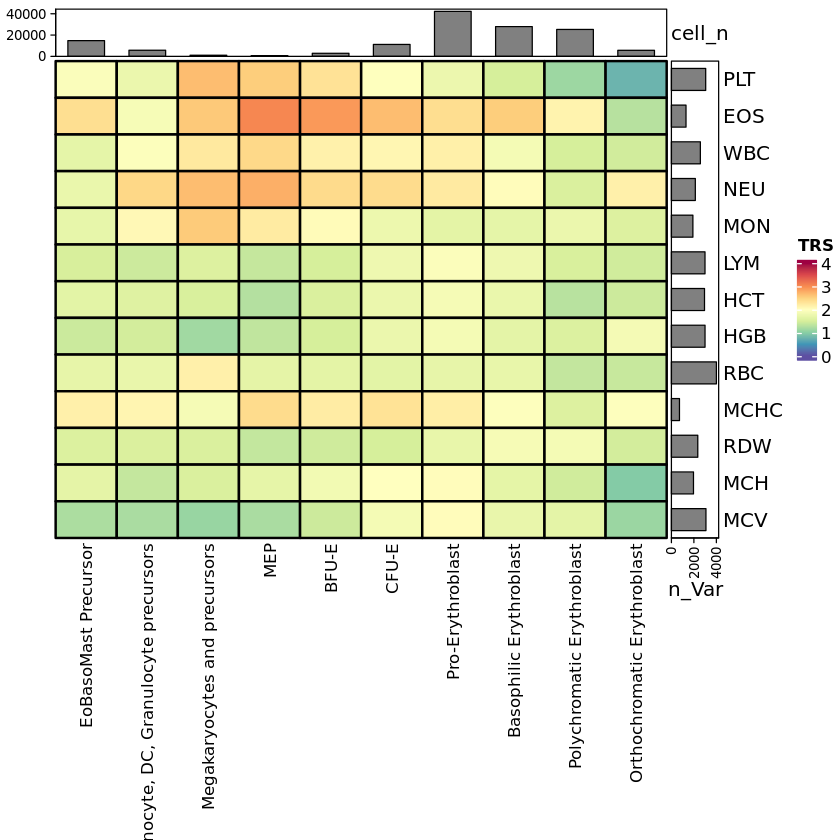

In [22]:
TF_sens_mean_traits <- read.csv("~/JAN_037_SCAVENGE//hg38_coord//Scavenge_matrix/Mean_TRS_NOT_TF_sensitive_credible_sets.csv", row.names = 1)
data <- as.matrix(t(TF_sens_mean_traits))

cell_number <- read.csv("~/JAN_037_SCAVENGE//hg38_coord/Scavenge_matrix/hg38_wnn_cell_number.csv")
colnames(cell_number)[1] <- 'pop'

variant_num <- read.csv("~/JAN_037_SCAVENGE//hg38_coord//BCX2_variants/credible_sets/NOT_TF_sensitive/NOT_TF_sensitive_credible_sets_number.csv", row.names = 1)
desired_order <- c('RBC', 'RDW', 'MCH', 'MCV', 'MCHC', 'HCT', 'HGB', 'EOS', 'WBC', 'NEU', 'MON', 'LYM', 'PLT') # Remove 'BAS'
variant_num <- variant_num[match(desired_order, rownames(variant_num)), , drop = FALSE]

column_order <- c("EoBasoMast Precursor", "Monocyte, DC, Granulocyte precursors", "Megakaryocytes and precursors", "MEP", "BFU-E",
                        "CFU-E", "Pro-Erythroblast", "Basophilic Erythroblast", "Polychromatic Erythroblast", "Orthochromatic Erythroblast")
row_order <- c("PLT","EOS", "WBC", "NEU", "MON","LYM", "HCT", "HGB", "RBC", "MCHC", "RDW","MCH","MCV") # Remove 'BAS' 

col1 = colorRamp2(seq(0, 4, length = 9), c('#5E4FA2', '#3F96B7', '#88CFA4', '#D7EF9B', '#FFFFBF', '#FDD380', '#F88D51', '#DC494C', '#9E0142'))
row_ha = rowAnnotation(n_Var = anno_barplot(variant_num))
column_ha = HeatmapAnnotation(cell_n = anno_barplot(cell_number$n_cells)
                        )
Heatmap(data, col = col1, column_order = column_order,name = "TRS", cluster_columns = FALSE,
        cluster_rows = FALSE, row_order = row_order,
       right_annotation = row_ha, top_annotation = column_ha, column_names_gp = gpar(fontsize = 10),
       rect_gp = gpar(col = "black", lwd = 2),
       heatmap_legend_param = list(at = seq(0, 4)))